# Characterizing Aberrations with Optuna

<a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/tutorials/1-getting-started/DTSG127_characterizing_aberrations_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack optuna # Uncomment if running on Colab/Kaggle.

This tutorial demonstrates how to identify the aberration type and aberration coefficient of an optical device using the image of a centered particle. DeepTrack2 lets you simulate a number of different optical aberrations, which you can use to identify aberrations you may find experimental setups using various methods.

## 1. Setup

Imports needed for this tutorial.

In [ ]:
import random

import deeptrack as dt
import numpy as np
from matplotlib import pyplot as plt
import optuna

## 2. Defining the Aberrations
We gather all aberration types that DeepTrack2 can simulate into a list. 

Aberrations in DeepTrack2 are wrappers of the more general `Zernike` feature, which introduces a phase to the pupil function based on the normalized Zernike polynomials. The property `coefficient` is a multiplier for the respective poynomial in the set of Zernike polynomials.

In [3]:
# Aberration types that can be simulated in DeepTrack2.
aberration_types = [
    dt.Piston,
    dt.VerticalTilt,
    dt.HorizontalTilt,
    dt.ObliqueAstigmatism,
    dt.Defocus,
    dt.Astigmatism,
    dt.ObliqueTrefoil,
    dt.VerticalComa,
    dt.HorizontalComa,
    dt.Trefoil,
    dt.SphericalAberration
]

## 3. Defining the Features

We define the features needed for this example. 

* `optics` - Flourescence microscope with a pixel size of 0.1 microns and a 256x256 camera.

* `particle` - Spherical particle centered in the image with 1 micrometer radius.


In [4]:
IMAGE_SIZE = 256

# Define optics.
optics = dt.Fluorescence(
    magnification=10,
    resolution=1e-6,
    wavelength=660e-9,
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE)
)

# Define scatterer.
particle = dt.Sphere(
    position=(IMAGE_SIZE//2, IMAGE_SIZE//2, 0 ),
    radius=1e-6
)

## 4. Combining the Features

To image the particle throught the aberrated microscope, choose a random aberration from the list and modify the pupil function of the `optics` microscope with `optics.pupil`.

In [5]:
# Pick a random aberration from the list.
aberration = random.choice(aberration_types)

# Pick a random aberration strength.
aberration = aberration(
    coefficient=lambda: (2 * np.random.rand() - 1) * 8
)

# Modify the pupil of the microscope with the aberration.
optics.pupil = aberration

Image the particle through the aberrated microscope.

Coefficient: -4.62174760037631
Radius: 1e-06


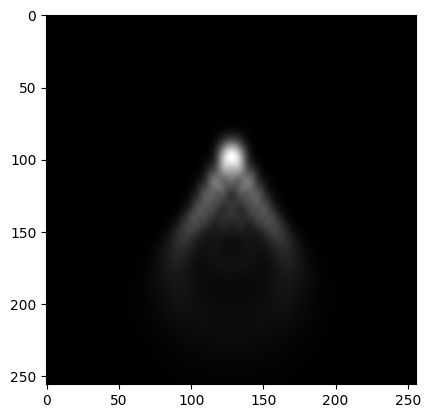

In [6]:
reference_image = optics(particle).resolve().squeeze()
plt.imshow(reference_image, cmap="gray")

print(f"{aberration}")
print(f"Coefficient: {aberration.coefficient()}")
print(f"Radius: {particle.radius()}")

## 5. Preparing the Simulation Function for Optuna

Optuna is a hyperparameter optimization framework which lets you explore a large number of parameters with a variety of search methods. In this tutorial we will use the default [Tree-Structured Parzen Estimator](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html#optuna.samplers.TPESampler) and restrict the search space to four parameters and use a simple RMSE loss function.

The parameters are:
* Aberration category
* Aberration coefficient
* Particle radii
* Z position of the particle (along the optical axis)


In [7]:
def simulate_aberrated_image(
    aberration_candidate, # Aberration category
    coefficient, # Aberration coefficient
    radius, # Particle radii
    z, # Z position
):
    # Get the aberration type and modify the pupil.
    simulated_aberration = aberration_candidate(coefficient=coefficient)
    optics.pupil = simulated_aberration

    # Instance the particle with the trial parameters.
    particle = dt.Sphere(
        radius=radius,
        position=(IMAGE_SIZE//2, IMAGE_SIZE//2, z)
    )

    # Image the particle through the aberrated microscope.
    simulated_image = optics(particle).resolve().squeeze()

    return simulated_image.astype(np.float32)

## 6. Preparing the Workflow for Optuna
The following function defines the search parameters and loss function that will be used in the study.

In [8]:
def objective(trial):

    # Varies aberration type using the list defined at the start.
    aberration_name = trial.suggest_categorical(
        "aberration_name", [cls.__name__ for cls in aberration_types]
    )
    aberration_type = next(
        cls for cls in aberration_types if cls.__name__ == aberration_name
    )

    # Varies aberration strength.
    coefficient = trial.suggest_float("coefficient", -10, 10) 

    # Varies particle radius.
    radius = trial.suggest_float("radius", 1e-7, 2.1e-6) 

    # Varies particle z-position.
    z = trial.suggest_float("z", -1, 1) 

    # Generates a simulated image with the parameters.
    simulated_image = simulate_aberrated_image(
        aberration_type,
        coefficient,
        radius,
        z,
    )

    # Pixel-wise RMSE comparison between the reference and the simulated image.
    loss = np.sqrt(np.mean(np.square(simulated_image - reference_image) ))

    return loss

## 7. Running the Study
We are now ready to run the Optuna study, which we will do for 200 trials. At each iteration the loss along with the parameters will be printed which allows you to track the progress.

In [9]:
# Run Optuna study.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

print("Best Loss:", study.best_value)
print("Best parameters:", study.best_trial.params)

[I 2026-03-16 10:06:43,576] A new study created in memory with name: no-name-f8dc6f48-2b36-4bd7-8950-842a926df4fc
[I 2026-03-16 10:06:44,533] Trial 0 finished with value: 0.12508142749597792 and parameters: {'aberration_name': 'HorizontalTilt', 'coefficient': -9.474025995624162, 'radius': 2.034094512931289e-06, 'z': -0.8071308949230842}. Best is trial 0 with value: 0.12508142749597792.
[I 2026-03-16 10:06:45,430] Trial 1 finished with value: 0.08002036183303865 and parameters: {'aberration_name': 'HorizontalTilt', 'coefficient': 5.292513908576328, 'radius': 1.6557914618697107e-06, 'z': -0.4481571261181887}. Best is trial 1 with value: 0.08002036183303865.
[I 2026-03-16 10:06:46,011] Trial 2 finished with value: 0.03276523538538248 and parameters: {'aberration_name': 'Defocus', 'coefficient': -0.4447060222613217, 'radius': 1.121914227597457e-06, 'z': 0.7047074887622846}. Best is trial 2 with value: 0.03276523538538248.
[I 2026-03-16 10:06:46,187] Trial 3 finished with value: 0.007166320

Best Loss: 0.00024509138249735856
Best parameters: {'aberration_name': 'VerticalComa', 'coefficient': -4.662222462739425, 'radius': 9.909959547095663e-07, 'z': 0.43119655108685284}


## 8.  Validating the Results
With the trial completed, we want to extract the parameters that minimized the loss function and reproduce the image.

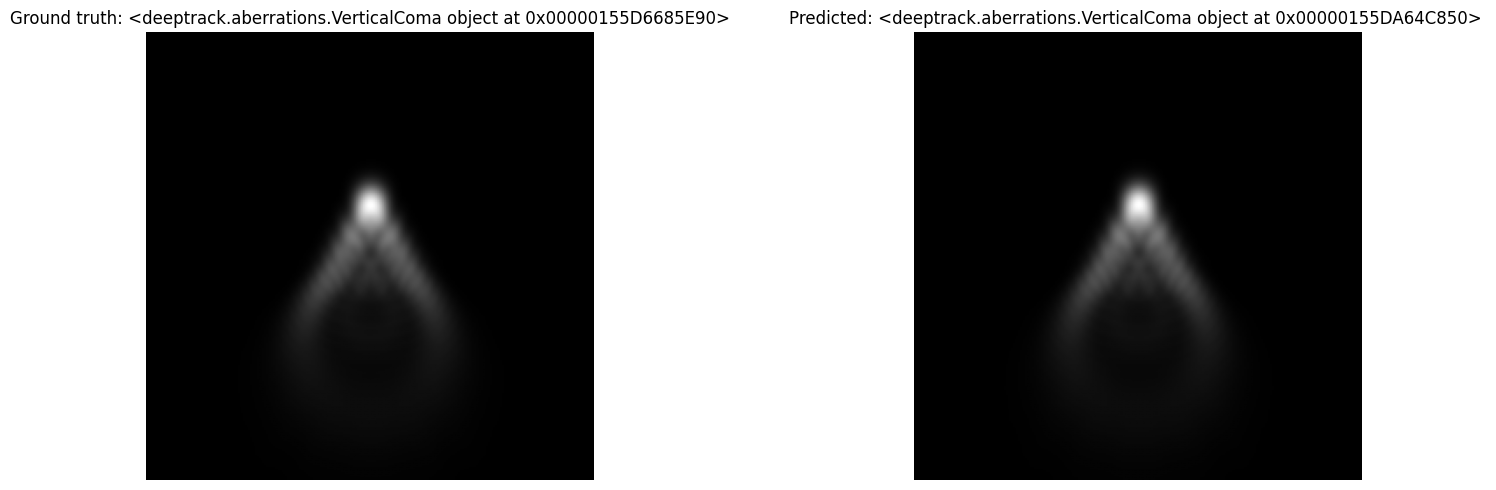

{'aberration_name': 'VerticalComa', 'coefficient': -4.662222462739425, 'radius': 9.909959547095663e-07, 'z': 0.43119655108685284}


In [10]:
# Get best parameters from the study.
best_params = study.best_trial.params
coeff = best_params["coefficient"]

# Reconstruct the image which had the optimal parameters.
predicted_aberration = study.best_params["aberration_name"]

# Convert string back to class.
aberration_class = next(
    cls for cls in aberration_types if cls.__name__ == predicted_aberration
)
# Create aberration instance.
predicted_aberration = aberration_class(coefficient=coeff)

optics.pupil = predicted_aberration
predicted_particle = dt.Sphere(
    radius=best_params["radius"],
    position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2, best_params["z"])
)

# Generate predicted image.
predicted_image = optics(predicted_particle).resolve().squeeze()

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].imshow(reference_image, cmap="gray")
ax[0].set_title(f"Ground truth: {aberration}")
ax[0].axis("off")

ax[1].imshow(predicted_image, cmap="gray")
ax[1].set_title(f"Predicted: {predicted_aberration} ")
ax[1].axis("off")

plt.tight_layout()
plt.show()
print(best_params)